## Problem 1
### Part 1

In [1]:
import sympy as sp
from sympy import symbols, pprint, Function, simplify, Derivative, nsimplify
from sympy import sin, cos, asin, acos, pi, diff, eye
from sympy import Matrix, latex, BlockMatrix, lambdify
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sympy import init_printing
init_printing() 

# Define Symbols
t  = symbols("t",   real=True)
l = symbols("l",  positive=True)   # Length of Link, assume Links are same length
#l2 = symbols("l2",  positive=True)   # Length of Link 2
#l3 = symbols("l3",  positive=True)   # Lrngth of link 3
k = symbols("k", positive=True) # Drag Coefficient
# Config Variables
x     = Function('x',     real=True)(t)
y     = Function('y',     real=True)(t)
theta = Function('theta', real=True)(t)
a1    = Function('a1',real=True)(t)
a2    = Function('a2',real=True)(t)


In [2]:
# Defining Various Helper Functions
def cross_matrix(vec):
    
    return Matrix([[0, -vec[2,0], vec[1,0]],
                      [vec[2,0], 0, -vec[0,0]],
                      [-vec[1,0], vec[0,0], 0]])

def uncross_matrix(mat):
    
    return Matrix([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])

def twist2vec(twist):
    m = Matrix.zeros(6,1)
    
    m[0:3,0] = uncross_matrix(twist[0:3,0:3])
    m[3:,0] = twist[0:3,3]
    
    return(m)
    
def R_z(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta), -sin(theta), 0], 
                   [sin(theta), cos(theta), 0],
                   [0, 0, 1]])

def R_y(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta),0, sin(theta)], 
                   [0, 1, 0],
                   [-sin(theta), 0, cos(theta)]])

def R_x(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[1, 0, 0],
                   [0, cos(theta), -sin(theta)], 
                   [0, sin(theta), cos(theta)]])
def T(R, p):
    m = Matrix.zeros(4,4)
    m[0:3, 0:3] = R
    m[:3, 3] = p
    m[3, 3] = 1
    return m


In [3]:
# Transform to Joint 1, then Translate to COM 1
T0COM1   = T(R_z(theta), Matrix([[x],[y],[0]]))
#TJ1toCOM1 = T(eye(3), Matrix([[l/2],[0],[0]]))
#T1 = simplify(Tjoint1 @ TJ1toCOM1) # World Frame to COM 1

T1J1= T(eye(3), Matrix([[-l/2],[0],[0]]))
TJ1rot = T(R_z(a1),Matrix([[0],[0],[0]]))
TJ1COM2 = T(eye(3),Matrix([[-l/2],[0],[0]]))
T0COM2= simplify(T0COM1@T1J1 @ TJ1rot @ TJ1COM2)

T1J2= T(eye(3),Matrix([[l/2],[0],[0]]))
TJ2rot = (T(R_z(a2),Matrix([[0],[0],[0]])))
TJ2COM3 = T(eye(3),Matrix([[-l/2],[0],[0]]))
T0COM3= simplify(T0COM1 @ T1J2 @ TJ2rot @ TJ2COM3)
##


In [4]:
T0COM1

⎡cos(θ(t))  -sin(θ(t))  0  x(t)⎤
⎢                              ⎥
⎢sin(θ(t))  cos(θ(t))   0  y(t)⎥
⎢                              ⎥
⎢    0          0       1   0  ⎥
⎢                              ⎥
⎣    0          0       0   1  ⎦

In [5]:
T0COM2

⎡                                            l⋅cos(a₁(t) + θ(t))   l⋅cos(θ(t))       ⎤
⎢cos(a₁(t) + θ(t))  -sin(a₁(t) + θ(t))  0  - ─────────────────── - ─────────── + x(t)⎥
⎢                                                     2                 2            ⎥
⎢                                                                                    ⎥
⎢                                            l⋅sin(a₁(t) + θ(t))   l⋅sin(θ(t))       ⎥
⎢sin(a₁(t) + θ(t))  cos(a₁(t) + θ(t))   0  - ─────────────────── - ─────────── + y(t)⎥
⎢                                                     2                 2            ⎥
⎢                                                                                    ⎥
⎢        0                  0           1                      0                     ⎥
⎢                                                                                    ⎥
⎣        0                  0           0                      1                     ⎦

In [6]:
T0COM3

⎡                                            l⋅cos(a₂(t) + θ(t))   l⋅cos(θ(t))       ⎤
⎢cos(a₂(t) + θ(t))  -sin(a₂(t) + θ(t))  0  - ─────────────────── + ─────────── + x(t)⎥
⎢                                                     2                 2            ⎥
⎢                                                                                    ⎥
⎢                                            l⋅sin(a₂(t) + θ(t))   l⋅sin(θ(t))       ⎥
⎢sin(a₂(t) + θ(t))  cos(a₂(t) + θ(t))   0  - ─────────────────── + ─────────── + y(t)⎥
⎢                                                     2                 2            ⎥
⎢                                                                                    ⎥
⎢        0                  0           1                      0                     ⎥
⎢                                                                                    ⎥
⎣        0                  0           0                      1                     ⎦

### Part 2 Compute Body Twists for each COM

In [7]:
# Body Twist For Each COM
bodytwist_COM1 = simplify(T0COM1.inv() @ diff(T0COM1, t))
bodytwist_COM1 = twist2vec(bodytwist_COM1) # Vectorized Bodytwist for COM 1
bodytwist_COM2 = simplify(T0COM2.inv() @ diff(T0COM2, t))
bodytwist_COM2 = twist2vec(bodytwist_COM2) # Vectorized Bodytwist for COM 2
bodytwist_COM3 = simplify(T0COM3.inv() @ diff(T0COM3, t))
bodytwist_COM3 = twist2vec(bodytwist_COM3) # Vectorized Bodytwist for COM 3

In [8]:
bodytwist_COM1

⎡                    0                    ⎤
⎢                                         ⎥
⎢                    0                    ⎥
⎢                                         ⎥
⎢                d                        ⎥
⎢                ──(θ(t))                 ⎥
⎢                dt                       ⎥
⎢                                         ⎥
⎢           d                    d        ⎥
⎢ sin(θ(t))⋅──(y(t)) + cos(θ(t))⋅──(x(t)) ⎥
⎢           dt                   dt       ⎥
⎢                                         ⎥
⎢            d                    d       ⎥
⎢- sin(θ(t))⋅──(x(t)) + cos(θ(t))⋅──(y(t))⎥
⎢            dt                   dt      ⎥
⎢                                         ⎥
⎣                    0                    ⎦

In [9]:
bodytwist_COM2

⎡                                                                 0                                                    ↪
⎢                                                                                                                      ↪
⎢                                                                 0                                                    ↪
⎢                                                                                                                      ↪
⎢                                                        d           d                                                 ↪
⎢                                                        ──(a₁(t)) + ──(θ(t))                                          ↪
⎢                                                        dt          dt                                                ↪
⎢                                                                                                                      ↪
⎢                        d      

In [10]:
bodytwist_COM3

⎡                                                                0                                                     ↪
⎢                                                                                                                      ↪
⎢                                                                0                                                     ↪
⎢                                                                                                                      ↪
⎢                                                       d           d                                                  ↪
⎢                                                       ──(a₂(t)) + ──(θ(t))                                           ↪
⎢                                                       dt          dt                                                 ↪
⎢                                                                                                                      ↪
⎢                      d        

### Part 3 Compute Jacobian

In [11]:
# Define q_dot
xd     = diff(x, t)
yd     = diff(y, t)
thetad = diff(theta, t)
a1d    = diff(a1, t)
a2d    = diff(a2, t)

q_dot = Matrix([xd, yd, thetad, a1d, a2d])

# Body Twist Jacobians
J1 = bodytwist_COM1.jacobian(q_dot)
J2 = bodytwist_COM2.jacobian(q_dot)
J3 = bodytwist_COM3.jacobian(q_dot)

In [12]:
J1

⎡    0           0      0  0  0⎤
⎢                              ⎥
⎢    0           0      0  0  0⎥
⎢                              ⎥
⎢    0           0      1  0  0⎥
⎢                              ⎥
⎢cos(θ(t))   sin(θ(t))  0  0  0⎥
⎢                              ⎥
⎢-sin(θ(t))  cos(θ(t))  0  0  0⎥
⎢                              ⎥
⎣    0           0      0  0  0⎦

In [13]:
J2

⎡            0                        0                              0                     0   0⎤
⎢                                                                                               ⎥
⎢            0                        0                              0                     0   0⎥
⎢                                                                                               ⎥
⎢            0                        0                              1                     1   0⎥
⎢                                                                                               ⎥
⎢                                                    l⋅sin(2⋅a₁(t) + θ(t))   l⋅sin(θ(t))        ⎥
⎢                                                  - ───────────────────── + ───────────        ⎥
⎢cos(2⋅a₁(t) + 2⋅θ(t)) + 1  sin(2⋅a₁(t) + 2⋅θ(t))              2                  2             ⎥
⎢─────────────────────────  ─────────────────────  ─────────────────────────────────────   0   0⎥
⎢   2⋅cos(a₁(t) + θ(

In [14]:
J3

⎡            0                        0                             0                   0   0 ⎤
⎢                                                                                             ⎥
⎢            0                        0                             0                   0   0 ⎥
⎢                                                                                             ⎥
⎢            0                        0                             1                   0   1 ⎥
⎢                                                                                             ⎥
⎢                                                  l⋅sin(2⋅a₂(t) + θ(t))   l⋅sin(θ(t))        ⎥
⎢                                                  ───────────────────── - ───────────        ⎥
⎢cos(2⋅a₂(t) + 2⋅θ(t)) + 1  sin(2⋅a₂(t) + 2⋅θ(t))            2                  2             ⎥
⎢─────────────────────────  ─────────────────────  ───────────────────────────────────  0   0 ⎥
⎢   2⋅cos(a₂(t) + θ(t))      2⋅cos(a₂(t)

### Part 4 Body Wrench

In [15]:
# Viscous Force Matrix
B = Matrix([
    [0, 0,        0, 0,   0,   0],
    [0, 0,        0, 0,   0,   0],
    [0, 0, 2/3*k*l**3, 0,   0,   0],
    [0, 0,        0, k*l, 0,   0],
    [0, 0,        0, 0, 2*k*l, 0],
    [0, 0,        0, 0,   0,   0]
])
def BodyWrench(bodytwist):
    return -B @ bodytwist

# Call BodyWrenches
F1 = BodyWrench(simplify(bodytwist_COM1))
F2 = simplify(BodyWrench(bodytwist_COM2))
F3 = BodyWrench(simplify(bodytwist_COM3))

In [16]:
F1

⎡                        0                         ⎤
⎢                                                  ⎥
⎢                        0                         ⎥
⎢                                                  ⎥
⎢                               3 d                ⎥
⎢         -0.666666666666667⋅k⋅l ⋅──(θ(t))         ⎥
⎢                                 dt               ⎥
⎢                                                  ⎥
⎢       ⎛          d                    d       ⎞  ⎥
⎢  -k⋅l⋅⎜sin(θ(t))⋅──(y(t)) + cos(θ(t))⋅──(x(t))⎟  ⎥
⎢       ⎝          dt                   dt      ⎠  ⎥
⎢                                                  ⎥
⎢       ⎛            d                    d       ⎞⎥
⎢-2⋅k⋅l⋅⎜- sin(θ(t))⋅──(x(t)) + cos(θ(t))⋅──(y(t))⎟⎥
⎢       ⎝            dt                   dt      ⎠⎥
⎢                                                  ⎥
⎣                        0                         ⎦

In [17]:
F2

⎡                                                                      0                                               ↪
⎢                                                                                                                      ↪
⎢                                                                      0                                               ↪
⎢                                                                                                                      ↪
⎢                                                                      3 ⎛d           d       ⎞                        ↪
⎢                                                -0.666666666666667⋅k⋅l ⋅⎜──(a₁(t)) + ──(θ(t))⎟                        ↪
⎢                                                                        ⎝dt          dt      ⎠                        ↪
⎢                                                                                                                      ↪
⎢    ⎛                      d   

In [18]:
F3

⎡                                                                       0                                              ↪
⎢                                                                                                                      ↪
⎢                                                                       0                                              ↪
⎢                                                                                                                      ↪
⎢                                                                       3 ⎛d           d       ⎞                       ↪
⎢                                                 -0.666666666666667⋅k⋅l ⋅⎜──(a₂(t)) + ──(θ(t))⎟                       ↪
⎢                                                                         ⎝dt          dt      ⎠                       ↪
⎢                                                                                                                      ↪
⎢     ⎛                      d  

### Part 5

In [19]:
def dynamics(t, state, params, alpha_dot_func):
    # Unpack state
    x_v, y_v, theta_v, a1_v, a2_v = state
    
    # Prescribed gait
    alpha_dot = alpha_dot_func(t)
    a1d_v = alpha_dot[0]
    a2d_v = alpha_dot[1]
    
    # A only depends on [theta, a1, a2] - drop x, y
    A_num   = np.array(A_lambda([theta_v, a1_v, a2_v], params), dtype=float)
    A11_num = A_num[:3, :3]
    A12_num = A_num[:3, 3:]
    
    # Solve: A11*Vfb + A12*alphadot = 0
    V_pose = -np.linalg.solve(A11_num, A12_num @ alpha_dot)
    
    return [V_pose[0], V_pose[1], V_pose[2], a1d_v, a2d_v]

### Part 6

In [21]:
# Part 6 - Reconstruction Matrix
A = J1.T @ B @ J1 + J2.T @ B @ J2 + J3.T @ B @ J3

# Extract submatrices
A11_sym = A[:3, :3]
A12_sym = A[:3, 3:]

A_recon = -A11_sym.LUsolve(A12_sym)


In [24]:
A_recon

⎡ ⎛                         ⎛                                                                                          ↪
⎢ ⎜                         ⎜                                                                                          ↪
⎢ ⎜                         ⎜                                                                                          ↪
⎢ ⎜                         ⎜                                                                                          ↪
⎢ ⎜                         ⎜                                                                                          ↪
⎢ ⎜                         ⎜                                                                                          ↪
⎢ ⎜                         ⎜                                                                                          ↪
⎢ ⎜                         ⎜                                                                                          ↪
⎢ ⎜                         ⎜   

### Part 7

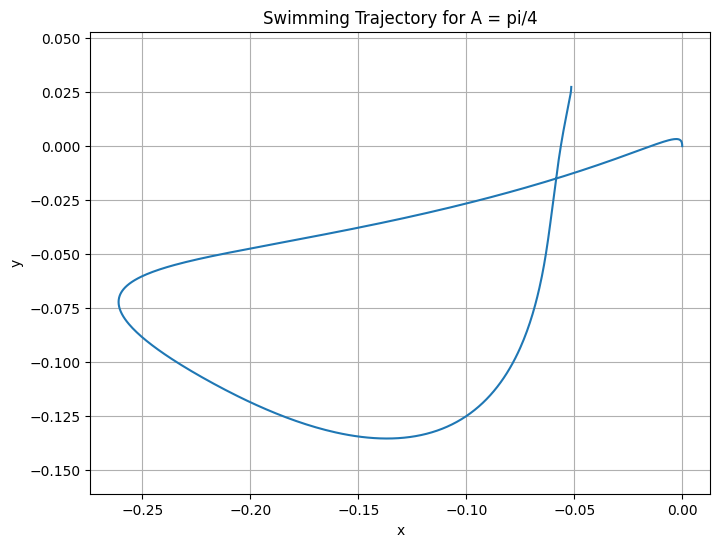

In [22]:
# Part 7 - Simulate Swimming with A = pi/4
params_sym = [k, l]
A_lambda = lambdify([[theta, a1, a2], params_sym], A, 'numpy')
params_val = [1, 1]  # k=1, l=1
A_amp      = float(pi/4)
phi_val    = float(pi/2)

# Gait function
def alpha_dot_gait(t):
    a1d = A_amp * 2*np.pi * np.cos(2*np.pi*t)
    a2d = A_amp * 2*np.pi * np.cos(2*np.pi*t + phi_val)
    return np.array([a1d, a2d])

# Initial conditions [x, y, theta, a1, a2]
y0     = [0, 0, 0, 0, 0]
t_span = (0, 1)
t_eval = np.linspace(0, 1, 500)

# Solve
sol = solve_ivp(
    lambda t, y: dynamics(t, y, params_val, alpha_dot_gait),
    t_span, y0, t_eval=t_eval, method='RK45'
)

# Plot x,y trajectory
plt.figure(figsize=(8, 6))
plt.plot(sol.y[0], sol.y[1])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Swimming Trajectory for A = pi/4')
plt.axis('equal')
plt.grid(True)
plt.show()

### Part 8

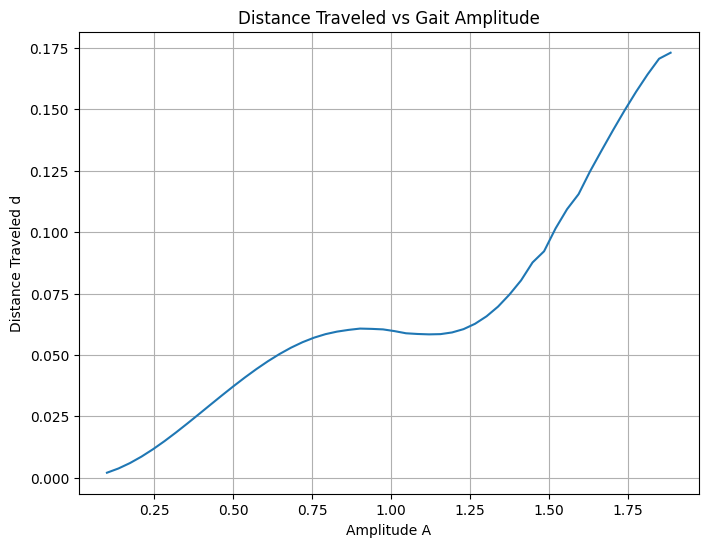

In [23]:
# Part 8 - Sweep Amplitude from 0.1 to 1.2*pi/2
A_vals    = np.linspace(0.1, 1.2*np.pi/2, 50)
distances = []
phi_val   = float(pi/2)

for A_amp_val in A_vals:
    
    def alpha_dot_sweep(t):
        a1d = A_amp_val * 2*np.pi * np.cos(2*np.pi*t)
        a2d = A_amp_val * 2*np.pi * np.cos(2*np.pi*t + phi_val)
        return np.array([a1d, a2d])
    
    sol = solve_ivp(
        lambda t, y: dynamics(t, y, params_val, alpha_dot_sweep),
        (0, 1), y0, t_eval=np.linspace(0, 1, 500), method='RK45'
    )
    
    # Final distance traveled
    x_final = sol.y[0, -1]
    y_final = sol.y[1, -1]
    d = np.sqrt(x_final**2 + y_final**2)
    distances.append(d)

# Plot distance vs amplitude
plt.figure(figsize=(8, 6))
plt.plot(A_vals, distances)
plt.xlabel('Amplitude A')
plt.ylabel('Distance Traveled d')
plt.title('Distance Traveled vs Gait Amplitude')
plt.grid(True)
plt.show()

## Problem 2
### Part 1

In [1]:
import numpy as np
 
def body_wrench_from_friction(V_b, f_par=1.0, f_lat=2.0):
    """
    Compute the body wrench (force/torque) on a single body element
    from snake-skin sliding friction.
 
    Snake-skin friction is ANISOTROPIC:
      - sliding backward (-x in body frame): force magnitude 2*f_par  (resists motion)
      - sliding forward  (+x in body frame): force magnitude   f_par  (resists motion)
      - sliding lateral  ( y in body frame): force magnitude   f_lat  (resists motion)
 
    The wrench always opposes the velocity direction, so F = -c * V_b
    where c is direction-dependent.
 
    Parameters
    ----------
    V_b : array-like, shape (3,)   [vx_b, vy_b, omega_b]
    f_par : float   forward sliding friction coefficient
    f_lat : float   lateral sliding friction coefficient
                    (backward = 2*f_par per the problem statement)
 
    Returns
    -------
    F_b : np.ndarray, shape (3,)   [Fx_b, Fy_b, tau_b]
    """
    V_b = np.asarray(V_b, dtype=float)
    vx, vy, omega = V_b
 
    # Coefficient depends on sign of vx
    if vx < 0:          # sliding backward → 2*f_par
        cx = 2.0 * f_par
    elif vx > 0:        # sliding forward  → f_par
        cx = f_par
    else:
        cx = f_par      # zero velocity: use forward coefficient (or 0)
 
    # Lateral and rotational drag
    cy    = f_lat
    c_rot = f_lat       # rotational drag same scale as lateral
 
    # Force opposes velocity
    F_b = np.array([-cx * vx,
                    -cy * vy,
                    -c_rot * omega])
    return F_b
 
 
# Quick smoke-test
if __name__ == "__main__":
    print("Cell 1 – body wrench test")
    print("  V_b = [1, 0, 0]  →", body_wrench_from_friction([1, 0, 0]))   # forward
    print("  V_b = [-1, 0, 0] →", body_wrench_from_friction([-1, 0, 0]))  # backward (2x)
    print("  V_b = [0, 1, 0]  →", body_wrench_from_friction([0, 1, 0]))   # lateral

Cell 1 – body wrench test
  V_b = [1, 0, 0]  → [-1. -0. -0.]
  V_b = [-1, 0, 0] → [ 2. -0. -0.]
  V_b = [0, 1, 0]  → [-0. -2. -0.]


In [2]:
from scipy.spatial.transform import Rotation
 
def rotation_matrix_2d(theta):
    """2D rotation matrix R(theta)."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s],
                     [s,  c]])
 
def body_jacobian_link(q, link_idx, L=1.0):
    """
    Compute the body Jacobian J_i for link i of a 3-link planar swimmer.
 
    State vector q = [x, y, theta, alpha1, alpha2]
      x, y, theta : pose of the base (link 0) in world frame
      alpha1      : joint angle between link 0 and link 1
      alpha2      : joint angle between link 1 and link 2
 
    Each link has length L.
    The body twist of link i is V_b_i = J_i(q) * q_dot.
 
    We use the convention that the body frame of each link is at its center.
    """
    x, y, theta, a1, a2 = q
 
    # Absolute orientations
    th0 = theta
    th1 = theta + a1
    th2 = theta + a1 + a2
 
    # Link center positions (world frame), measured from base origin
    c0 = np.array([x, y]) + L/2 * np.array([np.cos(th0), np.sin(th0)])
    c1 = (np.array([x, y])
          + L * np.array([np.cos(th0), np.sin(th0)])
          + L/2 * np.array([np.cos(th1), np.sin(th1)]))
    c2 = (np.array([x, y])
          + L * np.array([np.cos(th0), np.sin(th0)])
          + L * np.array([np.cos(th1), np.sin(th1)])
          + L/2 * np.array([np.cos(th2), np.sin(th2)]))
 
    centers = [c0, c1, c2]
    thetas  = [th0, th1, th2]
 
    ci  = centers[link_idx]
    thi = thetas[link_idx]
    Ri  = rotation_matrix_2d(thi)   # world ← body
 
    # Body Jacobian: maps q_dot → body twist [vx_b, vy_b, omega_b]
    # q = [x, y, theta, a1, a2], so J is 3×5
    J = np.zeros((3, 5))
 
    # Translational part in world frame, then rotate to body frame
    # d(ci)/d(q_k) gives world-frame velocity contribution
    # body velocity vb = R^T * (world velocity of ci - omega × r_offset)
    # For planar: vb_xy = R^T * dci/dqk * qdotk, omega_b = d(thi)/dqk * qdotk
 
    # --- d ci / d q ---
    if link_idx == 0:
        # c0 = [x + L/2 cos(th0), y + L/2 sin(th0)]
        dcx = np.zeros(5); dcy = np.zeros(5)
        dcx[0] = 1.0;  dcy[1] = 1.0   # d/dx, d/dy
        dcx[2] = -L/2 * np.sin(th0);  dcy[2] = L/2 * np.cos(th0)
        dth = np.zeros(5); dth[2] = 1.0
    elif link_idx == 1:
        dcx = np.zeros(5); dcy = np.zeros(5)
        dcx[0] = 1.0;  dcy[1] = 1.0
        dcx[2] = -L*np.sin(th0) - L/2*np.sin(th1)
        dcy[2] =  L*np.cos(th0) + L/2*np.cos(th1)
        dcx[3] = -L/2*np.sin(th1)
        dcy[3] =  L/2*np.cos(th1)
        dth = np.zeros(5); dth[2] = 1.0; dth[3] = 1.0
    else:  # link_idx == 2
        dcx = np.zeros(5); dcy = np.zeros(5)
        dcx[0] = 1.0;  dcy[1] = 1.0
        dcx[2] = -L*np.sin(th0) - L*np.sin(th1) - L/2*np.sin(th2)
        dcy[2] =  L*np.cos(th0) + L*np.cos(th1) + L/2*np.cos(th2)
        dcx[3] = -L*np.sin(th1) - L/2*np.sin(th2)
        dcy[3] =  L*np.cos(th1) + L/2*np.cos(th2)
        dcx[4] = -L/2*np.sin(th2)
        dcy[4] =  L/2*np.cos(th2)
        dth = np.zeros(5); dth[2] = 1.0; dth[3] = 1.0; dth[4] = 1.0
 
    # Rotate to body frame: [vbx; vby] = R^T * [vcx; vcy]
    Rt = Ri.T
    J[0, :] = Rt[0, 0] * dcx + Rt[0, 1] * dcy
    J[1, :] = Rt[1, 0] * dcx + Rt[1, 1] * dcy
    J[2, :] = dth
 
    return J
 
 
def net_force_snake_friction(q, q_dot, L=1.0, f_par=1.0, f_lat=2.0):
    """
    Compute the net generalized force vector on the 3-link swimmer
    due to snake-skin friction.
 
    τ = -Σ_i J_i^T(q) F_b_i(V_b_i)
 
    where V_b_i = J_i(q) * q_dot
 
    Parameters
    ----------
    q     : array (5,) – [x, y, theta, alpha1, alpha2]
    q_dot : array (5,) – time derivative of q
    L     : link length
    f_par, f_lat : friction coefficients
 
    Returns
    -------
    tau : array (5,) – generalized forces
    """
    q     = np.asarray(q, dtype=float)
    q_dot = np.asarray(q_dot, dtype=float)
    tau   = np.zeros(5)
 
    for i in range(3):
        Ji   = body_jacobian_link(q, i, L=L)
        Vbi  = Ji @ q_dot
        Fbi  = body_wrench_from_friction(Vbi, f_par=f_par, f_lat=f_lat)
        tau += Ji.T @ Fbi   # note: already negated inside body_wrench
 
    return tau
 
 
# Quick test
if __name__ == "__main__":
    q_test     = np.array([0., 0., 0., 0.3, -0.3])
    q_dot_test = np.array([0.1, 0., 0., 0.5, -0.5])
    print("\nCell 2 – net generalized force:")
    print("  tau =", net_force_snake_friction(q_test, q_dot_test))


Cell 2 – net generalized force:
  tau = [ 0.03454709 -1.40477261 -4.04378479 -2.63901218 -0.47766824]


### Part 2

In [3]:
from scipy.spatial.transform import Rotation
 
def rotation_matrix_2d(theta):
    """2D rotation matrix R(theta)."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s],
                     [s,  c]])
 
def body_jacobian_link(q, link_idx, L=1.0):
    """
    Compute the body Jacobian J_i for link i of a 3-link planar swimmer.
 
    State vector q = [x, y, theta, alpha1, alpha2]
      x, y, theta : pose of the base (link 0) in world frame
      alpha1      : joint angle between link 0 and link 1
      alpha2      : joint angle between link 1 and link 2
 
    Each link has length L.
    The body twist of link i is V_b_i = J_i(q) * q_dot.
 
    We use the convention that the body frame of each link is at its center.
    """
    x, y, theta, a1, a2 = q
 
    # Absolute orientations
    th0 = theta
    th1 = theta + a1
    th2 = theta + a1 + a2
 
    # Link center positions (world frame), measured from base origin
    c0 = np.array([x, y]) + L/2 * np.array([np.cos(th0), np.sin(th0)])
    c1 = (np.array([x, y])
          + L * np.array([np.cos(th0), np.sin(th0)])
          + L/2 * np.array([np.cos(th1), np.sin(th1)]))
    c2 = (np.array([x, y])
          + L * np.array([np.cos(th0), np.sin(th0)])
          + L * np.array([np.cos(th1), np.sin(th1)])
          + L/2 * np.array([np.cos(th2), np.sin(th2)]))
 
    centers = [c0, c1, c2]
    thetas  = [th0, th1, th2]
 
    ci  = centers[link_idx]
    thi = thetas[link_idx]
    Ri  = rotation_matrix_2d(thi)   # world ← body
 
    # Body Jacobian: maps q_dot → body twist [vx_b, vy_b, omega_b]
    # q = [x, y, theta, a1, a2], so J is 3×5
    J = np.zeros((3, 5))
 
    # Translational part in world frame, then rotate to body frame
    # d(ci)/d(q_k) gives world-frame velocity contribution
    # body velocity vb = R^T * (world velocity of ci - omega × r_offset)
    # For planar: vb_xy = R^T * dci/dqk * qdotk, omega_b = d(thi)/dqk * qdotk
 
    # --- d ci / d q ---
    if link_idx == 0:
        # c0 = [x + L/2 cos(th0), y + L/2 sin(th0)]
        dcx = np.zeros(5); dcy = np.zeros(5)
        dcx[0] = 1.0;  dcy[1] = 1.0   # d/dx, d/dy
        dcx[2] = -L/2 * np.sin(th0);  dcy[2] = L/2 * np.cos(th0)
        dth = np.zeros(5); dth[2] = 1.0
    elif link_idx == 1:
        dcx = np.zeros(5); dcy = np.zeros(5)
        dcx[0] = 1.0;  dcy[1] = 1.0
        dcx[2] = -L*np.sin(th0) - L/2*np.sin(th1)
        dcy[2] =  L*np.cos(th0) + L/2*np.cos(th1)
        dcx[3] = -L/2*np.sin(th1)
        dcy[3] =  L/2*np.cos(th1)
        dth = np.zeros(5); dth[2] = 1.0; dth[3] = 1.0
    else:  # link_idx == 2
        dcx = np.zeros(5); dcy = np.zeros(5)
        dcx[0] = 1.0;  dcy[1] = 1.0
        dcx[2] = -L*np.sin(th0) - L*np.sin(th1) - L/2*np.sin(th2)
        dcy[2] =  L*np.cos(th0) + L*np.cos(th1) + L/2*np.cos(th2)
        dcx[3] = -L*np.sin(th1) - L/2*np.sin(th2)
        dcy[3] =  L*np.cos(th1) + L/2*np.cos(th2)
        dcx[4] = -L/2*np.sin(th2)
        dcy[4] =  L/2*np.cos(th2)
        dth = np.zeros(5); dth[2] = 1.0; dth[3] = 1.0; dth[4] = 1.0
 
    # Rotate to body frame: [vbx; vby] = R^T * [vcx; vcy]
    Rt = Ri.T
    J[0, :] = Rt[0, 0] * dcx + Rt[0, 1] * dcy
    J[1, :] = Rt[1, 0] * dcx + Rt[1, 1] * dcy
    J[2, :] = dth
 
    return J
 
 
def net_force_snake_friction(q, q_dot, L=1.0, f_par=1.0, f_lat=2.0):
    """
    Compute the net generalized force vector on the 3-link swimmer
    due to snake-skin friction.
 
    τ = -Σ_i J_i^T(q) F_b_i(V_b_i)
 
    where V_b_i = J_i(q) * q_dot
 
    Parameters
    ----------
    q     : array (5,) – [x, y, theta, alpha1, alpha2]
    q_dot : array (5,) – time derivative of q
    L     : link length
    f_par, f_lat : friction coefficients
 
    Returns
    -------
    tau : array (5,) – generalized forces
    """
    q     = np.asarray(q, dtype=float)
    q_dot = np.asarray(q_dot, dtype=float)
    tau   = np.zeros(5)
 
    for i in range(3):
        Ji   = body_jacobian_link(q, i, L=L)
        Vbi  = Ji @ q_dot
        Fbi  = body_wrench_from_friction(Vbi, f_par=f_par, f_lat=f_lat)
        tau += Ji.T @ Fbi   # note: already negated inside body_wrench
 
    return tau
 
 
# Quick test
if __name__ == "__main__":
    q_test     = np.array([0., 0., 0., 0.3, -0.3])
    q_dot_test = np.array([0.1, 0., 0., 0.5, -0.5])
    print("\nCell 2 – net generalized force:")
    print("  tau =", net_force_snake_friction(q_test, q_dot_test))


Cell 2 – net generalized force:
  tau = [ 0.03454709 -1.40477261 -4.04378479 -2.63901218 -0.47766824]


### Part 3

In [4]:
from scipy.optimize import fsolve
 
def swimmer_velocity_fsolve(q, alpha_dot, L=1.0, f_par=1.0, f_lat=2.0):
    """
    For a freely floating 3-link swimmer (no external torques on the base),
    find the base velocity V_P = [xdot, ydot, thetadot] given shape velocities
    alpha_dot = [alpha1_dot, alpha2_dot].
 
    The force balance (statics of locomotion) requires the net external
    generalized force on the POSE DOFs to be zero:
 
        tau_pose = 0   →   A11 * V_P + A12 * alpha_dot = 0
 
    We use fsolve to solve for V_P.
 
    Parameters
    ----------
    q         : array (5,)  – current configuration [x, y, theta, a1, a2]
    alpha_dot : array (2,)  – joint velocities [a1dot, a2dot]
 
    Returns
    -------
    V_P : array (3,)  – [xdot, ydot, thetadot]
    """
    q         = np.asarray(q, dtype=float)
    alpha_dot = np.asarray(alpha_dot, dtype=float)
 
    def residual(V_P):
        # Full q_dot = [V_P (3), alpha_dot (2)]
        q_dot = np.concatenate([V_P, alpha_dot])
        tau   = net_force_snake_friction(q, q_dot, L=L, f_par=f_par, f_lat=f_lat)
        # Pose DOFs are indices 0,1,2 (x, y, theta)
        return tau[:3]
 
    V_P0 = np.zeros(3)   # initial guess
    V_P_sol, info, ier, msg = fsolve(residual, V_P0, full_output=True)
 
    if ier != 1:
        print(f"  fsolve warning: {msg}")
    return V_P_sol
 
 
# --- Random configuration and joint velocities ---
np.random.seed(42)
q_rand         = np.array([0., 0.,
                            np.random.uniform(-np.pi, np.pi),
                            np.random.uniform(-1., 1.),
                            np.random.uniform(-1., 1.)])
alpha_dot_rand = np.random.uniform(-1., 1., size=2)
 
V_P = swimmer_velocity_fsolve(q_rand, alpha_dot_rand)
 
print("Cell 3 – swimmer velocity (fsolve)")
print(f"  Configuration q      = {q_rand}")
print(f"  Joint velocities     = {alpha_dot_rand}")
print(f"  Base velocity V_P    = {V_P}")
 
# Verify residual
q_dot_check = np.concatenate([V_P, alpha_dot_rand])
tau_check   = net_force_snake_friction(q_rand, q_dot_check)
print(f"  Residual (tau_pose)  = {tau_check[:3]}  (should be ~0)")

Cell 3 – swimmer velocity (fsolve)
  Configuration q      = [ 0.          0.         -0.78828768  0.90142861  0.46398788]
  Joint velocities     = [ 0.19731697 -0.68796272]
  Base velocity V_P    = [-0.04856174 -0.1203313   0.0759871 ]
  Residual (tau_pose)  = [ 6.93889390e-17 -2.77555756e-17 -1.11022302e-16]  (should be ~0)


### Part 4


Cell 4 – integrating with solve_ivp …
  fsolve warning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  Integration succeeded: The solver successfully reached the end of the integration interval.


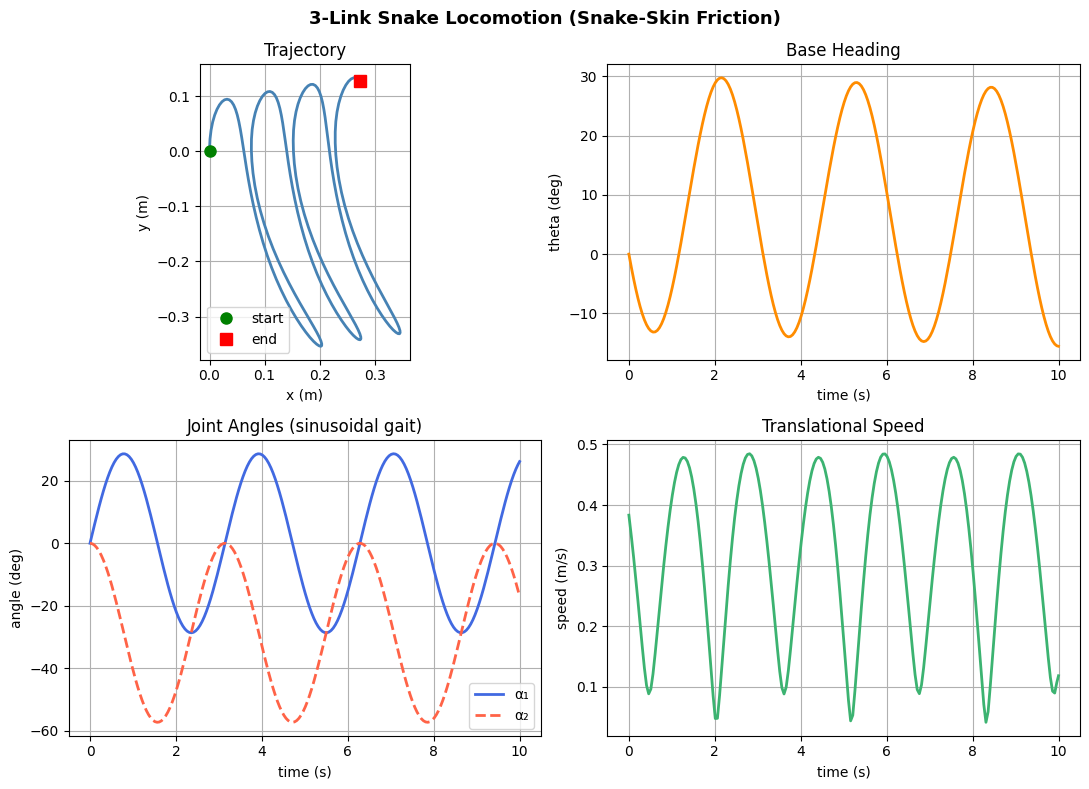

In [5]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
 
def dynamics(t, state, omega=1.0, A=0.5, L=1.0, f_par=1.0, f_lat=2.0):
    """
    Dynamics function for the 3-link snake swimmer.
 
    State: [x, y, theta, alpha1, alpha2]  (5 DOFs)
 
    The gait is sinusoidal:
        alpha1(t) = A * sin(omega * t)
        alpha2(t) = A * sin(omega * t + pi/2)   ← quarter-phase offset
        alpha1_dot = A * omega * cos(omega * t)
        alpha2_dot = A * omega * cos(omega * t + pi/2)
 
    Base velocity V_P = [xdot, ydot, thetadot] is solved via fsolve
    (zero net force on pose DOFs).
 
    Returns d(state)/dt = [xdot, ydot, thetadot, alpha1dot, alpha2dot]
    """
    x, y, theta, a1, a2 = state
 
    # Prescribed sinusoidal gait
    alpha1_dot = A * omega * np.cos(omega * t)
    alpha2_dot = A * omega * np.cos(omega * t + np.pi / 2)
    alpha_dot  = np.array([alpha1_dot, alpha2_dot])
 
    # Current configuration (alpha values come from state)
    q = np.array([x, y, theta, a1, a2])
 
    # Solve for base velocity
    V_P = swimmer_velocity_fsolve(q, alpha_dot, L=L, f_par=f_par, f_lat=f_lat)
 
    return [V_P[0], V_P[1], V_P[2], alpha1_dot, alpha2_dot]
 
 
# --- Initial conditions: straight snake at origin ---
A     = 0.5      # gait amplitude (rad)
omega = 2.0      # gait frequency (rad/s)
t_end = 10.0     # simulation time (s)
 
state0 = [0., 0., 0., 0., 0.]   # [x, y, theta, a1, a2]
 
print("\nCell 4 – integrating with solve_ivp …")
sol = solve_ivp(
    fun=lambda t, s: dynamics(t, s, omega=omega, A=A),
    t_span=(0, t_end),
    y0=state0,
    method='RK45',
    max_step=0.05,
    rtol=1e-4, atol=1e-6
)
print(f"  Integration {'succeeded' if sol.success else 'FAILED'}: {sol.message}")
 
# --- Plot results ---
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle("3-Link Snake Locomotion (Snake-Skin Friction)", fontsize=13, fontweight='bold')
 
t   = sol.t
x, y, theta = sol.y[0], sol.y[1], sol.y[2]
a1, a2      = sol.y[3], sol.y[4]
 
# Trajectory
ax = axes[0, 0]
ax.plot(x, y, 'steelblue', lw=2)
ax.plot(x[0], y[0], 'go', ms=8, label='start')
ax.plot(x[-1], y[-1], 'rs', ms=8, label='end')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title('Trajectory'); ax.legend(); ax.set_aspect('equal'); ax.grid(True)
 
# Heading
ax = axes[0, 1]
ax.plot(t, np.rad2deg(theta), color='darkorange', lw=2)
ax.set_xlabel('time (s)'); ax.set_ylabel('theta (deg)')
ax.set_title('Base Heading'); ax.grid(True)
 
# Joint angles
ax = axes[1, 0]
ax.plot(t, np.rad2deg(a1), label='α₁', color='royalblue', lw=2)
ax.plot(t, np.rad2deg(a2), label='α₂', color='tomato', lw=2, linestyle='--')
ax.set_xlabel('time (s)'); ax.set_ylabel('angle (deg)')
ax.set_title('Joint Angles (sinusoidal gait)'); ax.legend(); ax.grid(True)
 
# Speed
speed = np.sqrt(np.gradient(x, t)**2 + np.gradient(y, t)**2)
ax = axes[1, 1]
ax.plot(t, speed, color='mediumseagreen', lw=2)
ax.set_xlabel('time (s)'); ax.set_ylabel('speed (m/s)')
ax.set_title('Translational Speed'); ax.grid(True)
 
plt.tight_layout()
plt.show()
